# BDA Practica 2 — Model Comparison and Explainability

Three predictive pipelines are trained on the integrated dataset:

1. **Integrated Core** — Logistic Regression / Random Forest on a small set of widely-available indicators (age, BMI, gender, risk-factor flags).
2. **Integrated Enriched** — same model family with an enriched feature set that adds clinical variables (BP, max heart rate, mental/physical unhealthy days, etc.).
3. **KG Embedding Classifier** — Logistic Regression / Random Forest trained on **graph-derived features** built by holding out outcome aggregate nodes, embedding the remaining typed RDF adjacency with TruncatedSVD, and then composing per-record feature vectors from dataset, population-group, and indicator node embeddings (plus interactions).

This is the **second analytical pipeline** required by P2: ML over KG embeddings. The graph-based exploration is in `02_knowledge_graph_exploration.ipynb`.

Run the full pipeline (`python run_all_pipeline.py --skip-landing --strict`) before opening this notebook.

## 1. Setup and Reports

In [9]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
try:
    import matplotlib.pyplot as plt
except Exception as exc:
    plt = None
    print(f'Matplotlib unavailable; showing tables only: {exc}')


def locate_project_root(start: Path) -> Path:
    current = start.resolve()
    for _ in range(8):
        if (current / 'run_all_pipeline.py').exists():
            return current
        current = current.parent
    raise FileNotFoundError('Could not locate project root')

PROJECT_ROOT = locate_project_root(Path.cwd())
REPORTS_DIR = PROJECT_ROOT / 'Part5_Analysis_zone' / 'reports'

integrated_core = json.loads((REPORTS_DIR / 'integrated_core_report.json').read_text(encoding='utf-8'))
integrated_enriched = json.loads((REPORTS_DIR / 'integrated_enriched_report.json').read_text(encoding='utf-8'))
kg_embedding = json.loads((REPORTS_DIR / 'kg_embedding_report.json').read_text(encoding='utf-8'))
summary = json.loads((REPORTS_DIR / 'summary_report.json').read_text(encoding='utf-8'))

MODELS = [
    ('Integrated Core',     integrated_core,     '#3B7DD8'),
    ('Integrated Enriched', integrated_enriched, '#218A4D'),
    ('KG Embedding ML',     kg_embedding,        '#C24B65'),
]
for name, report, _ in MODELS:
    print(f'{name:22s} selected model = {report["selected_model"]}')

Integrated Core        selected model = rf_balanced
Integrated Enriched    selected model = rf_balanced
KG Embedding ML        selected model = rf_embedding


## 2. Test-set Performance Comparison

We compare the three pipelines on the same test split semantics: stratified by outcome, decision threshold tuned for F1 on the training fold. Note that the KG embedding pipeline uses a stratified record-level sample over the same integrated dataset, so the comparison is fair in distribution but uses different features (graph node embeddings vs raw indicators).

In [10]:
metrics_rows = []
for name, report, _ in MODELS:
    m = report['test_metrics']
    metrics_rows.append({
        'pipeline': name,
        'selected_model': report['selected_model'],
        'accuracy':  m.get('accuracy'),
        'precision': m.get('precision'),
        'recall':    m.get('recall'),
        'f1':        m.get('f1'),
        'roc_auc':   m.get('roc_auc'),
        'pr_auc':    m.get('pr_auc'),
    })
metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,pipeline,selected_model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Integrated Core,rf_balanced,0.793437,0.443525,0.586942,0.505253,0.817460,0.493966
1,Integrated Enriched,rf_balanced,0.840029,0.549253,0.612213,0.579027,0.869287,0.624815
2,KG Embedding ML,rf_embedding,0.821083,0.501500,0.698052,0.583673,0.860561,0.573290


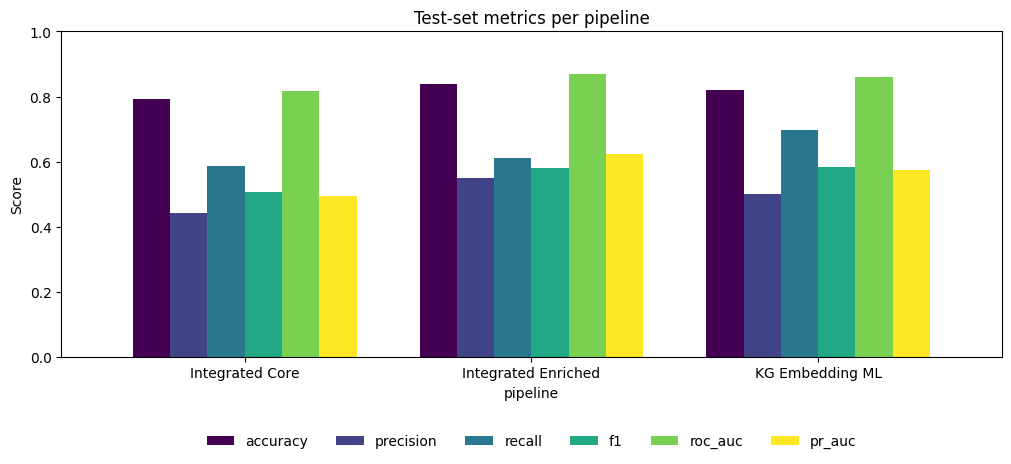

,accuracy,precision,recall,f1,roc_auc,pr_auc
pipeline,,,,,,
Integrated Core,0.793437,0.443525,0.586942,0.505253,0.817460,0.493966
Integrated Enriched,0.840029,0.549253,0.612213,0.579027,0.869287,0.624815
KG Embedding ML,0.821083,0.501500,0.698052,0.583673,0.860561,0.573290


In [11]:
to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
values = metrics_df.set_index('pipeline')[to_plot]
if plt is not None:
    fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
    values.plot(kind='bar', ax=ax, width=0.78, colormap='viridis')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score')
    ax.set_title('Test-set metrics per pipeline')
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.32), ncol=6, frameon=False)
    plt.xticks(rotation=0)
    plt.show()
values


## 3. Confusion Matrices

Confusion matrices on the held-out test set give a clearer picture of trade-offs between false positives and false negatives. This is particularly important in heart-disease screening where false negatives carry a high cost.

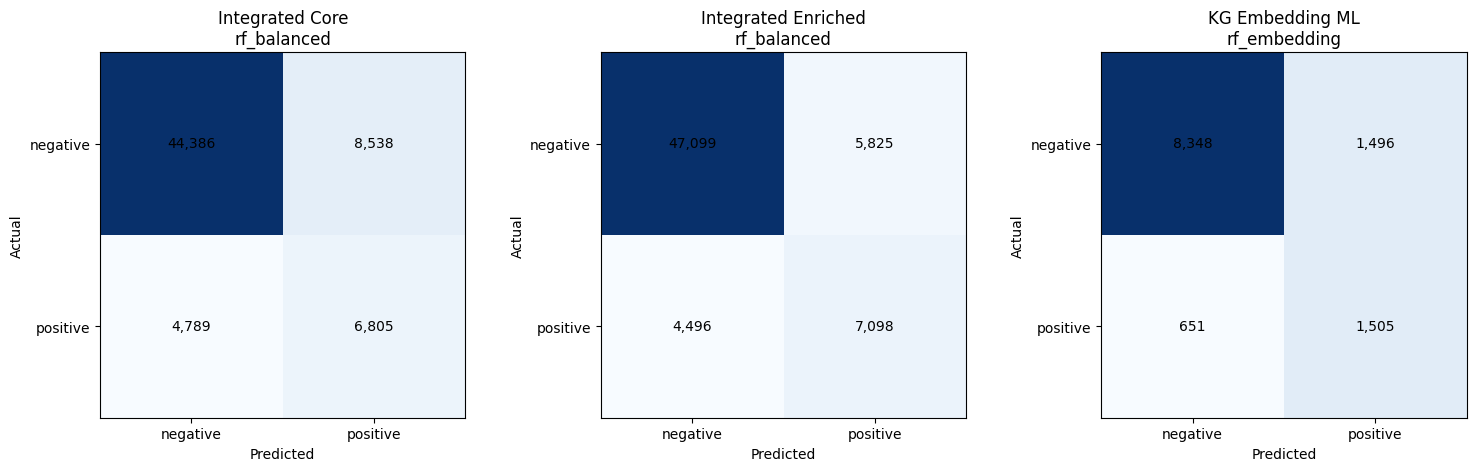

,pipeline,tn,fp,fn,tp
0,Integrated Core,44386,8538,4789,6805
1,Integrated Enriched,47099,5825,4496,7098
2,KG Embedding ML,8348,1496,651,1505


In [12]:
confusion_rows = []

for name, report, _ in MODELS:
    cm = np.array(report['test_metrics']['confusion_matrix'])
    
    confusion_rows.append({
        'pipeline': name,
        'tn': cm[0, 0],
        'fp': cm[0, 1],
        'fn': cm[1, 0],
        'tp': cm[1, 1]
    })

if plt is not None:
    fig, axes = plt.subplots(
        1,
        len(MODELS),
        figsize=(15, 4.6),
        constrained_layout=True
    )

    # Por si solo hay un modelo, axes no es una lista
    axes = np.atleast_1d(axes)

    for ax, (name, report, _) in zip(axes, MODELS):
        cm = np.array(report['test_metrics']['confusion_matrix'])

        ax.imshow(cm, cmap='Blues')
        ax.set_title(f'{name}\n{report["selected_model"]}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['negative', 'positive'])
        ax.set_yticklabels(['negative', 'positive'])

        for i in range(2):
            for j in range(2):
                ax.text(
                    j,
                    i,
                    f'{cm[i, j]:,}',
                    ha='center',
                    va='center',
                    color='black'
                )

    plt.show()

pd.DataFrame(confusion_rows)

## 4. Cross-Validation Stability

Comparing the cross-validation mean (and standard deviation) of the candidate models for each pipeline gives a sense of stability. Wider gaps between the chosen model and the alternative imply that the metric used for selection is meaningful.

In [13]:
cv_rows = []
for name, report, _ in MODELS:
    candidate_models = report.get('candidate_models', {})
    for model_name, scores in candidate_models.items():
        cv_rows.append({
            'pipeline': name,
            'model':    model_name,
            'cv_score_mean': scores.get('cv_roc_auc_mean', scores.get('cv_pr_auc_mean')),
            'cv_score_std':  scores.get('cv_roc_auc_std',  scores.get('cv_pr_auc_std')),
            'scoring':       'roc_auc' if 'cv_roc_auc_mean' in scores else 'pr_auc',
        })
cv_df = pd.DataFrame(cv_rows)
cv_df

,pipeline,model,cv_score_mean,cv_score_std,scoring
0,Integrated Core,logreg_balanced,0.747249,0.001041,roc_auc
1,Integrated Core,rf_balanced,0.819942,0.001296,roc_auc
2,Integrated Enriched,logreg_balanced,0.553232,0.002109,pr_auc
3,Integrated Enriched,rf_balanced,0.632740,0.001151,pr_auc
4,KG Embedding ML,logreg_embedding,0.548754,0.010166,pr_auc
5,KG Embedding ML,rf_embedding,0.556456,0.007867,pr_auc


## 5. Feature Importance — Tabular Models

The two integrated pipelines store the top ranked features that drove the chosen classifier. Random Forest exposes Gini importance; Logistic Regression exposes the absolute value of the standardized coefficients. Both are appropriate proxies for relative feature contribution.

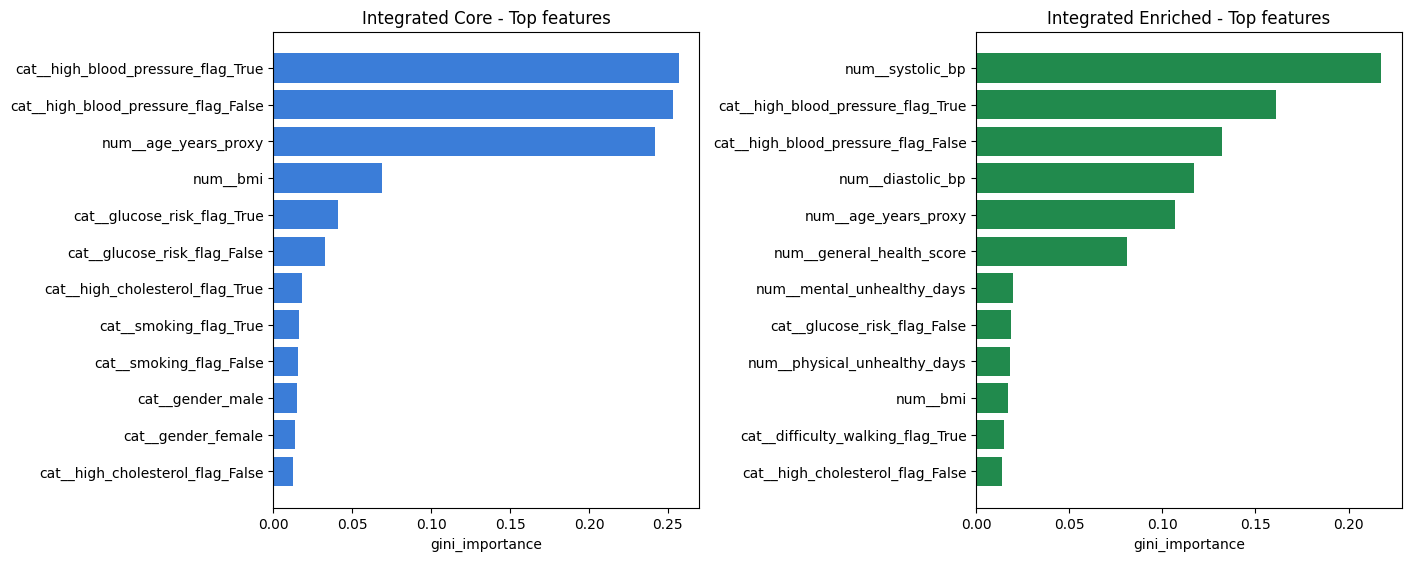

,feature,importance,importance_type,pipeline
0,cat__high_blood_pressure_flag_True,0.256744,gini_importance,Integrated Core
1,cat__high_blood_pressure_flag_False,0.253413,gini_importance,Integrated Core
2,num__age_years_proxy,0.241747,gini_importance,Integrated Core
3,num__bmi,0.068568,gini_importance,Integrated Core
4,cat__glucose_risk_flag_True,0.041111,gini_importance,Integrated Core
5,cat__glucose_risk_flag_False,0.032884,gini_importance,Integrated Core
6,cat__high_cholesterol_flag_True,0.017968,gini_importance,Integrated Core
7,cat__smoking_flag_True,0.016211,gini_importance,Integrated Core
8,cat__smoking_flag_False,0.015547,gini_importance,Integrated Core
9,cat__gender_male,0.014870,gini_importance,Integrated Core


In [14]:
def top_importance_frame(report: dict, pipeline: str, top_n: int = 12) -> pd.DataFrame:
    return pd.DataFrame(report.get('top_feature_importance', [])[:top_n]).assign(pipeline=pipeline)

importance_table = pd.concat([
    top_importance_frame(integrated_core, 'Integrated Core'),
    top_importance_frame(integrated_enriched, 'Integrated Enriched'),
], ignore_index=True)

if plt is not None and not importance_table.empty:
    def plot_feature_importance(report: dict, title: str, ax, color: str = '#4F8DCB', top_n: int = 12) -> None:
        items = report.get('top_feature_importance', [])[:top_n][::-1]
        if not items:
            ax.set_title(f'{title}: no importance available')
            return
        labels = [item['feature'] for item in items]
        values = [item['importance'] for item in items]
        ax.barh(labels, values, color=color)
        ax.set_title(title)
        ax.set_xlabel(items[-1].get('importance_type', 'importance'))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)
    plot_feature_importance(integrated_core, 'Integrated Core - Top features', axes[0], '#3B7DD8')
    plot_feature_importance(integrated_enriched, 'Integrated Enriched - Top features', axes[1], '#218A4D')
    plt.show()
importance_table


## 6. KG Embedding ML — Structural Inspection

The KG embedding classifier predicts the same target (heart disease outcome) using **only graph-derived features**:

- A *dataset* embedding (16 dimensions).
- A *population-group* embedding (16 dimensions, encodes the age × gender concept).
- Mean embeddings of the *observed*, *risk-factor*, and *protective-factor* indicators connected to the record.
- Interaction features (`dataset ⊙ group`, `|dataset − group|`).
- Three count statistics (observed/risk/protective indicators).

Heart-disease outcome aggregate nodes are **held out** while embeddings are generated to avoid label leakage.

In [15]:
print('Graph:')
for key, value in kg_embedding['graph'].items():
    print(f'  {key:30s} {value:,}' if isinstance(value, int) else f'  {key:30s} {value}')
print('Samples:')
for key, value in kg_embedding['samples'].items():
    if isinstance(value, dict):
        print(f'  {key}:')
        for k2, v2 in value.items():
            print(f'    {k2}: {v2}')
    else:
        print(f'  {key:30s} {value}')
print(f'Selected model: {kg_embedding["selected_model"]}')
print(f'Decision threshold: {kg_embedding["decision_threshold"]:.4f}')

Graph:
  triples                        5,573
  held_out_outcome_measurements  62
  embedding_edges                6,254
  embedded_nodes                 703
Samples:
  rows_total                     60000
  positive_labels                10782
  negative_labels                49218
  source_distribution:
    heart_disease_health_indicators: 47184
    cardiovascular_disease: 12761
    heart_disease_cleveland: 55
Selected model: rf_embedding
Decision threshold: 0.6278


In [16]:
embeddings_path = REPORTS_DIR / 'kg_node_embeddings.csv'
if embeddings_path.exists():
    emb = pd.read_csv(embeddings_path)
    print(f'Loaded {len(emb):,} node embeddings (dim={emb.shape[1]-1})')
    emb.head()

Loaded 703 node embeddings (dim=16)


### 6.1 2D Projection of the Node Embeddings

A simple 2D projection (using the first two embedding dimensions) highlights how the SVD over the typed RDF adjacency separates datasets, indicators and population groups in the latent space.

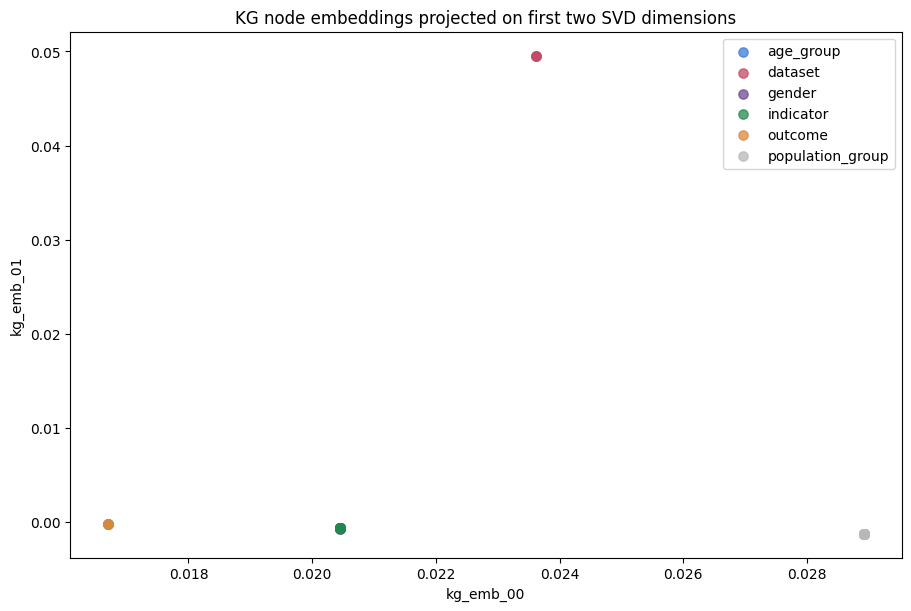

In [17]:
if embeddings_path.exists():
    BASE = 'https://example.org/bda/health-risk/'

    def node_kind(name: str) -> str:
        if name.startswith(BASE + 'dataset/'):
            return 'dataset'
        if name.startswith(BASE + 'indicator/'):
            return 'indicator'
        if name.startswith(BASE + 'population-group/'):
            return 'population_group'
        if name.startswith(BASE + 'age-group/'):
            return 'age_group'
        if name.startswith(BASE + 'gender/'):
            return 'gender'
        if name.startswith(BASE + 'outcome/'):
            return 'outcome'
        if name.startswith(BASE + 'aggregate-measurement/'):
            return 'aggregate'
        if '#predicate' in name:
            return 'predicate'
        return 'other'

    emb_viz = emb.copy()
    emb_viz['kind'] = emb_viz['node'].map(node_kind)
    interesting = ['dataset', 'indicator', 'population_group', 'outcome', 'age_group', 'gender']
    emb_viz = emb_viz[emb_viz['kind'].isin(interesting)]

    if plt is not None:
        fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
        colors = {
            'dataset': '#C24B65',
            'indicator': '#218A4D',
            'population_group': '#B8B8B8',
            'outcome': '#D88A3B',
            'age_group': '#3B7DD8',
            'gender': '#6A4C93',
        }
        for kind, group in emb_viz.groupby('kind'):
            ax.scatter(group['kg_emb_00'], group['kg_emb_01'], label=kind, alpha=0.75, s=45, color=colors.get(kind))
        ax.set_title('KG node embeddings projected on first two SVD dimensions')
        ax.set_xlabel('kg_emb_00')
        ax.set_ylabel('kg_emb_01')
        ax.legend(loc='best')
        plt.show()
    emb_viz[['node', 'kind', 'kg_emb_00', 'kg_emb_01']].head(20)


### 6.2 Label distribution of the KG-embedding training set

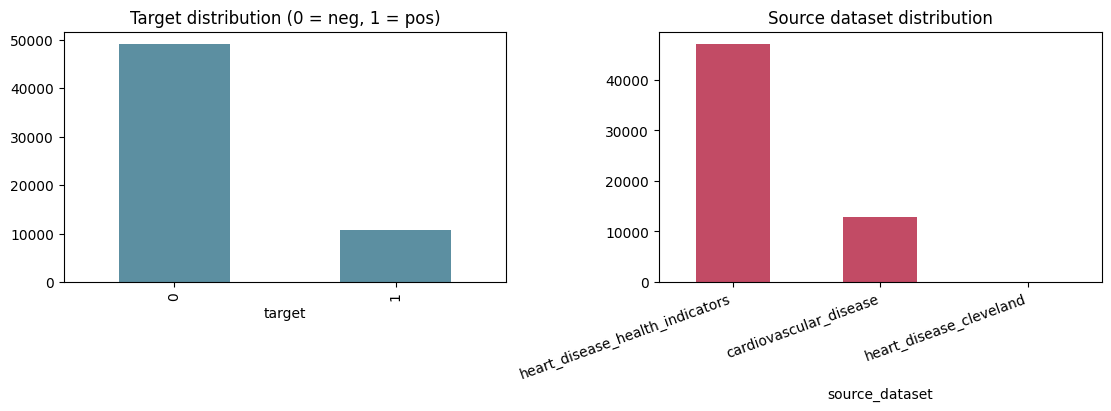

In [18]:
audit_path = REPORTS_DIR / 'kg_embedding_training_data.csv'
if audit_path.exists():
    audit = pd.read_csv(audit_path)
    if plt is not None:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
        audit['target'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#5C8FA1')
        axes[0].set_title('Target distribution (0 = neg, 1 = pos)')
        axes[0].set_xlabel('target')
        audit['source_dataset'].value_counts().plot(kind='bar', ax=axes[1], color='#C24B65')
        axes[1].set_title('Source dataset distribution')
        plt.xticks(rotation=20, ha='right')
        plt.show()
    audit.describe(include='all').T
